# Naive continual learning

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.


100%|██████████| 6.53G/6.53G [03:08<00:00, 37.2MB/s]

Extracting files...


ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Preprocess data**

- Group-disjoint clips for all three tasks

In [5]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [6]:
# BASE
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


In [7]:
# TASK 1
preprocess_group_split(task1_split, cfg.TASK_1, output_root=cfg.TASK1_ROOT)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 5

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task1


In [8]:
# TASK 2
preprocess_group_split(task2_split, cfg.TASK_2, output_root=cfg.TASK2_ROOT)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 5

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task2


In [9]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [10]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam']


In [11]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14}


## **Create Loaders**

In [12]:
base_test = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"), class_to_idx=class_to_idx)
base_test_loader = DataLoader(base_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)

task1_train_loader = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader   = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader  = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test        = ConcatDataset([base_test, task1_test])
combined_test_loader = DataLoader(combined_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

## **Upload Model**

Load the ResNet50 teacher, then grow the head to cover Task 1

In [13]:
model = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
model.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))
model = unfreeze_all(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]


In [14]:
model = expand_classifier(model, len(ALL_CLASSES_LIST))
model = unfreeze_all(model).to(device)

In [15]:
snapshots = []
results_baseline = evaluate_all_tasks(model, device, base_test_loader, [task1_test_loader], [combined_test_loader])
snapshots.append(results_baseline)

  base             -> Acc=0.9387  Loss=0.1979
  task1_only        -> Acc=0.0000  Loss=4.4398
  combined_t1       -> Acc=0.6180  Loss=1.6470


In [16]:
print(f"classifier: in={model.fc.in_features}  out={model.fc.out_features}")

classifier: in=256  out=15


## **Task One**

In [17]:
set_seed(cfg.SEED)
train_task1 = train_model(model, task1_train_loader, task1_val_loader, num_epochs=5, device=device)

Epoch [1/5] | Train Acc: 0.5033 Loss: 1.8049 | Val Acc: 0.8630 Loss: 0.7239


Epoch [2/5] | Train Acc: 0.9523 Loss: 0.3402 | Val Acc: 0.9452 Loss: 0.3212


Epoch [3/5] | Train Acc: 0.9826 Loss: 0.1411 | Val Acc: 0.9452 Loss: 0.2143


Epoch [4/5] | Train Acc: 0.9892 Loss: 0.0827 | Val Acc: 0.9589 Loss: 0.1839


Epoch [5/5] | Train Acc: 0.9892 Loss: 0.0622 | Val Acc: 0.9041 Loss: 0.2693


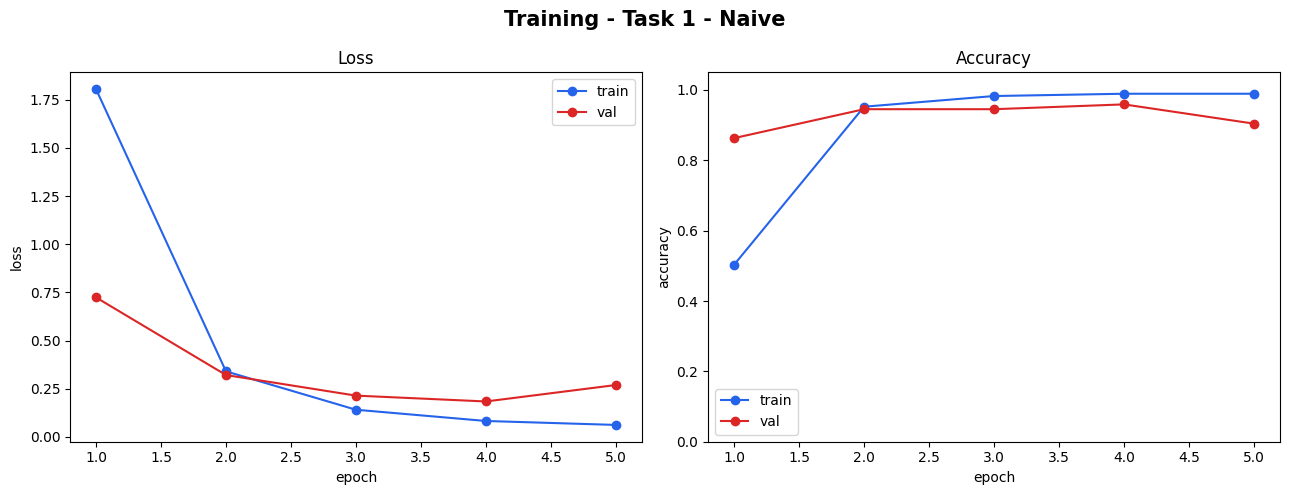

In [18]:
plot_training_results(train_task1, task_name="Task 1 - Naive")

In [19]:
results_after_t1 = evaluate_all_tasks(model, device, base_test_loader, [task1_test_loader], [combined_test_loader])
snapshots.append(results_after_t1)

  base             -> Acc=0.2406  Loss=2.6197
  task1_only        -> Acc=0.9636  Loss=0.1445
  combined_t1       -> Acc=0.4876  Loss=1.7741


Test Accuracy: 0.4876


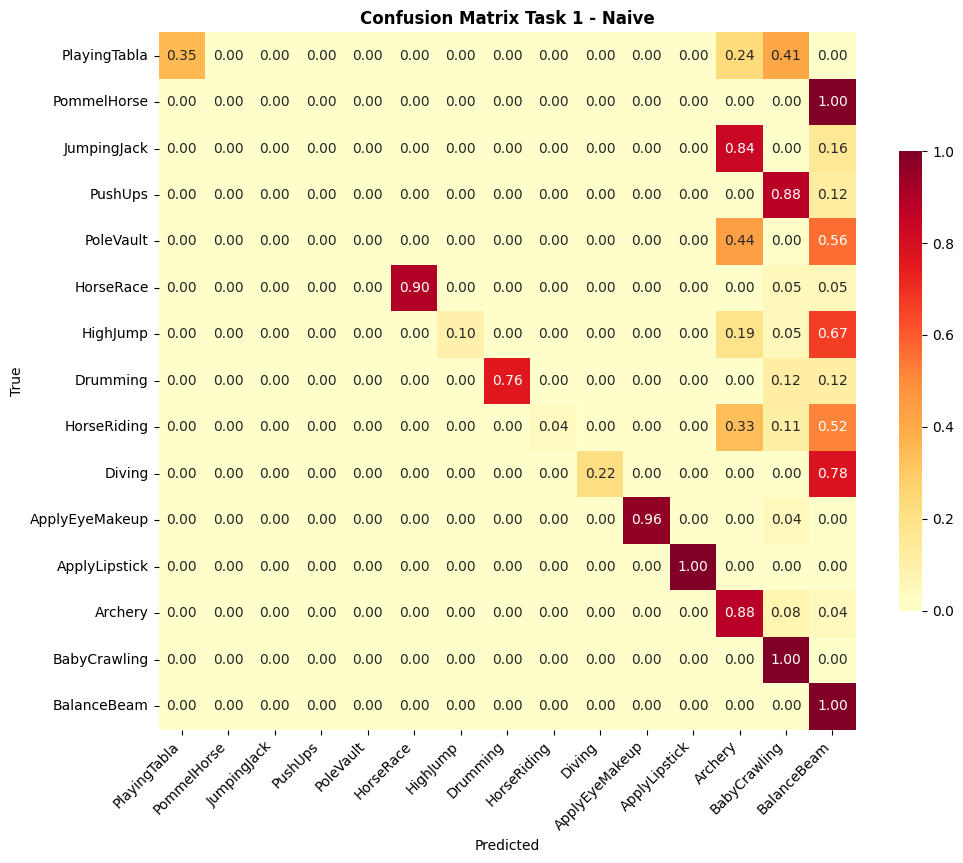

In [20]:
_, all_preds, all_labels = test_model(model, combined_test_loader, device)
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Task 1 - Naive")

In [21]:
print_detailed_metrics(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, len(cfg.SELECTED_CLASSES)),
                       split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)))


METRICS FOR 15 CLASSES
  Accuracy : 0.4876
  F1-Score : 0.4287

PER-CLASS REPORT
                precision    recall  f1-score   support

  PlayingTabla       1.00      0.35      0.52        17
   PommelHorse       0.00      0.00      0.00        19
   JumpingJack       0.00      0.00      0.00        19
       PushUps       0.00      0.00      0.00        16
     PoleVault       0.00      0.00      0.00        25
     HorseRace       1.00      0.90      0.95        20
      HighJump       1.00      0.10      0.17        21
      Drumming       1.00      0.76      0.86        25
   HorseRiding       1.00      0.04      0.07        27
        Diving       1.00      0.22      0.36        23
ApplyEyeMakeup       1.00      0.96      0.98        25
 ApplyLipstick       1.00      1.00      1.00        20
       Archery       0.33      0.88      0.48        25
  BabyCrawling       0.42      1.00      0.59        23
   BalanceBeam       0.16      1.00      0.28        17

      accuracy      

## **Task 2**

In [22]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BoxingPunchingBag': 15, 'BoxingSpeedBag': 16, 'BrushingTeeth': 17, 'CliffDiving': 18, 'CricketBowling': 19}


In [23]:
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
task2_val   = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "val"),   class_to_idx=class_to_idx)
task2_test  = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "test"),  class_to_idx=class_to_idx)

task2_train_loader = DataLoader(task2_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task2_val_loader   = DataLoader(task2_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_test_loader  = DataLoader(task2_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test2        = ConcatDataset([base_test, task1_test, task2_test])
combined_test_loader2 = DataLoader(combined_test2, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

In [24]:
model = expand_classifier(model, len(ALL_CLASSES_LIST))
model = unfreeze_all(model).to(device)

In [25]:
results_baseline_t2 = evaluate_all_tasks(model, device, base_test_loader,
                                         [task1_test_loader, task2_test_loader],
                                         [combined_test_loader, combined_test_loader2])

  base             -> Acc=0.2406  Loss=2.6831
  task1_only        -> Acc=0.9636  Loss=0.1666
  task2_only        -> Acc=0.0000  Loss=4.9952
  combined_t1       -> Acc=0.4876  Loss=1.8234
  combined_t2       -> Acc=0.3576  Loss=2.6688


In [26]:
set_seed(cfg.SEED)
train_task2 = train_model(model, task2_train_loader, task2_val_loader, num_epochs=5, device=device)

Epoch [1/5] | Train Acc: 0.4076 Loss: 2.2345 | Val Acc: 0.7059 Loss: 0.9658


Epoch [2/5] | Train Acc: 0.9503 Loss: 0.5011 | Val Acc: 0.9882 Loss: 0.2953


Epoch [3/5] | Train Acc: 0.9801 Loss: 0.1888 | Val Acc: 0.9882 Loss: 0.1927


Epoch [4/5] | Train Acc: 0.9861 Loss: 0.1002 | Val Acc: 0.9294 Loss: 0.1888


Epoch [5/5] | Train Acc: 0.9940 Loss: 0.0760 | Val Acc: 1.0000 Loss: 0.0955


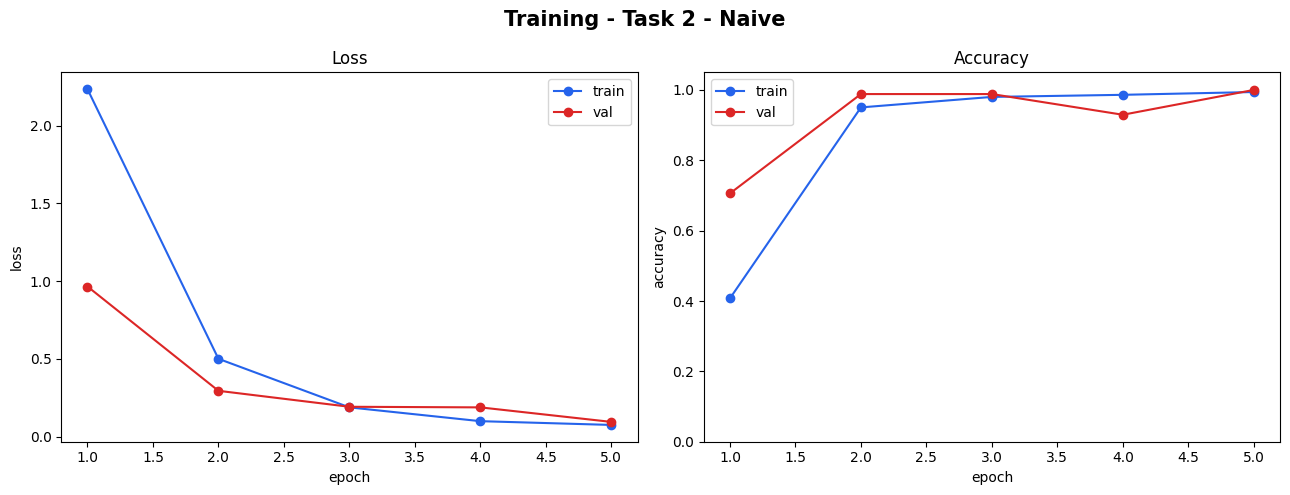

In [27]:
plot_training_results(train_task2, task_name="Task 2 - Naive")

In [28]:
results_after_t2 = evaluate_all_tasks(model, device, base_test_loader,
                                      [task1_test_loader, task2_test_loader],
                                      [combined_test_loader, combined_test_loader2])
snapshots.append(results_after_t2)

  base             -> Acc=0.0142  Loss=4.5328
  task1_only        -> Acc=0.0182  Loss=3.9903
  task2_only        -> Acc=0.9573  Loss=0.1498
  combined_t1       -> Acc=0.0155  Loss=4.3475
  combined_t2       -> Acc=0.2665  Loss=3.2287


Test Accuracy: 0.2665


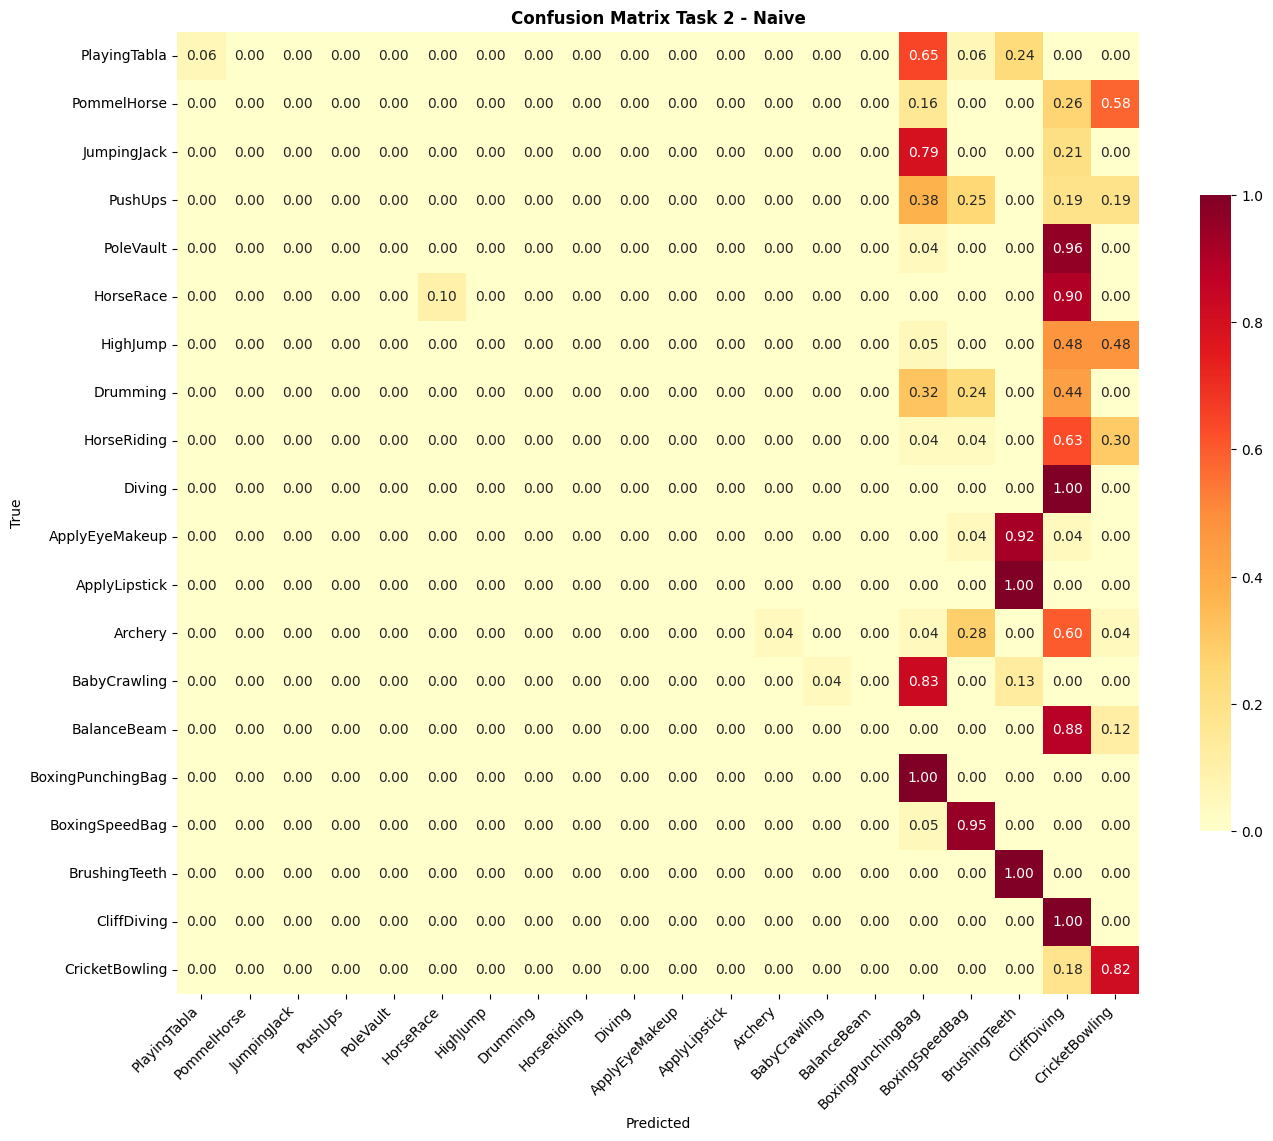

In [29]:
_, all_preds, all_labels = test_model(model, combined_test_loader2, device)
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Task 2 - Naive")

In [30]:
split_new = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1)
print_detailed_metrics(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, split_new),
                       split_new=(split_new, len(ALL_CLASSES_LIST)))


METRICS FOR 20 CLASSES
  Accuracy : 0.2665
  F1-Score : 0.1453

PER-CLASS REPORT
                   precision    recall  f1-score   support

     PlayingTabla       1.00      0.06      0.11        17
      PommelHorse       0.00      0.00      0.00        19
      JumpingJack       0.00      0.00      0.00        19
          PushUps       0.00      0.00      0.00        16
        PoleVault       0.00      0.00      0.00        25
        HorseRace       1.00      0.10      0.18        20
         HighJump       0.00      0.00      0.00        21
         Drumming       0.00      0.00      0.00        25
      HorseRiding       0.00      0.00      0.00        27
           Diving       0.00      0.00      0.00        23
   ApplyEyeMakeup       0.00      0.00      0.00        25
    ApplyLipstick       0.00      0.00      0.00        20
          Archery       1.00      0.04      0.08        25
     BabyCrawling       1.00      0.04      0.08        23
      BalanceBeam       0.00    

## **Forgetting**

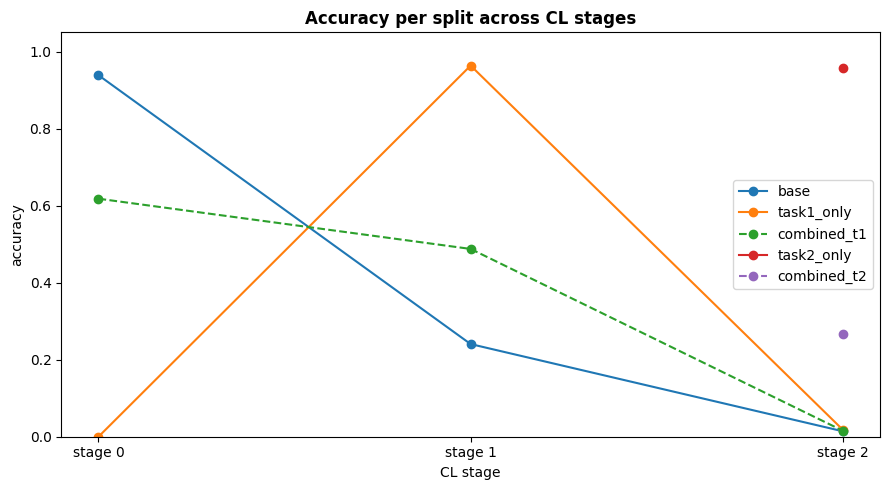

In [31]:
plot_cl_forgetting(snapshots)